# EDA — Prediction de Demande Pharmaceutique

Exploration complete du dataset avant modelisation avec RandomForestRegressor.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa','axes.grid':True,'grid.alpha':0.4})
sns.set_palette('husl')
print('Librairies OK')

Librairies OK


## 1. Chargement

In [2]:
df = pd.read_csv('data.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
print('Shape:', df.shape)
print('Periode:', df['date'].min().date(), '->', df['date'].max().date())
print('Medicaments:', df['idmedicament'].nunique())
df.head(8)

Shape: (43860, 11)
Periode: 2024-01-01 -> 2025-12-31
Medicaments: 60


,idmedicament,nommedicament,prix,qtechete,date,season,jourférié,stock_actuel,month,day_of_week,is_weekend
0,13,Maxilase,16.0,17,2024-03-06,Spring,0,95,3,2,0
1,18,Aerius,45.2,5,2025-01-02,Winter,0,168,1,3,0
2,31,Imodium,21.5,15,2024-10-23,Autumn,0,206,10,2,0
3,32,Debridat,22.3,23,2024-08-04,Summer,0,198,8,6,1
4,38,Dulcolax,17.8,16,2025-07-25,Summer,0,248,7,4,0
5,6,Efferalgan,13.2,32,2024-11-20,Autumn,0,193,11,2,0
6,10,Codeine,65.0,8,2025-05-02,Spring,0,51,5,4,0
7,43,Tahor,52.0,12,2024-11-04,Autumn,0,142,11,0,0


## 2. Qualite des donnees

In [3]:
miss = df.isnull().sum()
print('Valeurs manquantes:')
print(miss[miss > 0] if miss.any() else 'Aucune')
print('Doublons:', df.duplicated().sum())
print('Stock negatif:', (df['stock_actuel'] < 0).sum())
print('Qtechete negatif:', (df['qtechete'] < 0).sum())

Valeurs manquantes:
Aucune
Doublons: 0
Stock negatif: 0
Qtechete negatif: 0


## 3. Distribution de la cible qtechete

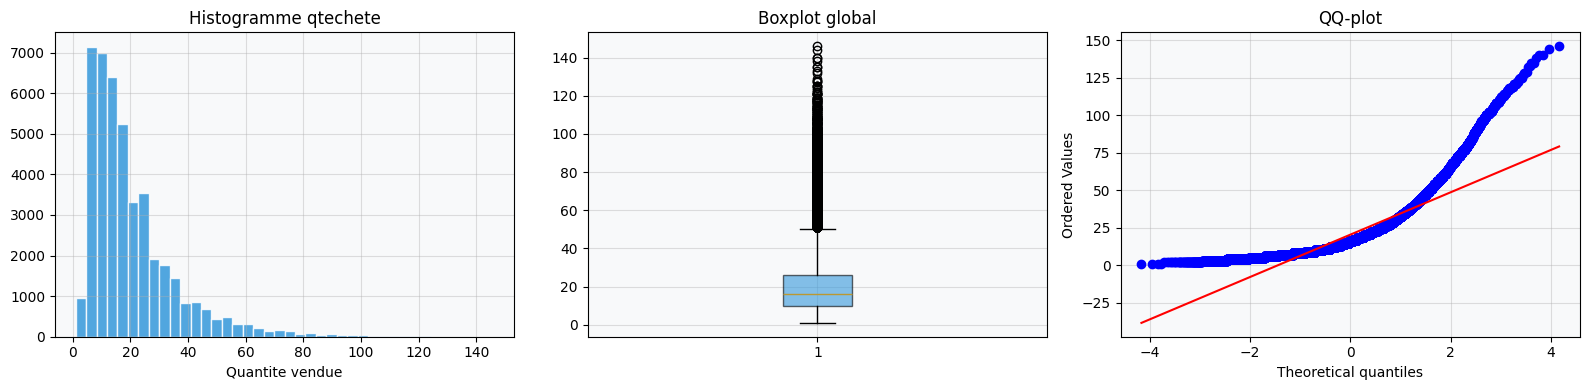

Skewness: 2.138
Kurtosis: 6.409


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['qtechete'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogramme qtechete')
axes[0].set_xlabel('Quantite vendue')
axes[1].boxplot(df['qtechete'], patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Boxplot global')
stats.probplot(df['qtechete'], dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot')
plt.tight_layout()
plt.show()
print('Skewness:', round(df['qtechete'].skew(), 3))
print('Kurtosis:', round(df['qtechete'].kurtosis(), 3))

## 4. Analyse par medicament

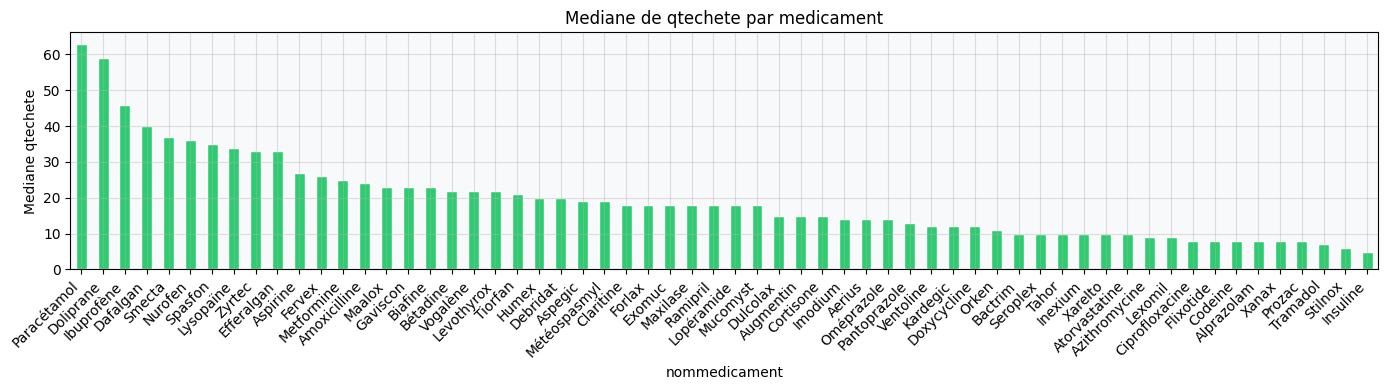

In [5]:
top_meds = df.groupby('nommedicament')['qtechete'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
top_meds.plot(kind='bar', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Mediane de qtechete par medicament')
ax.set_ylabel('Mediane qtechete')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

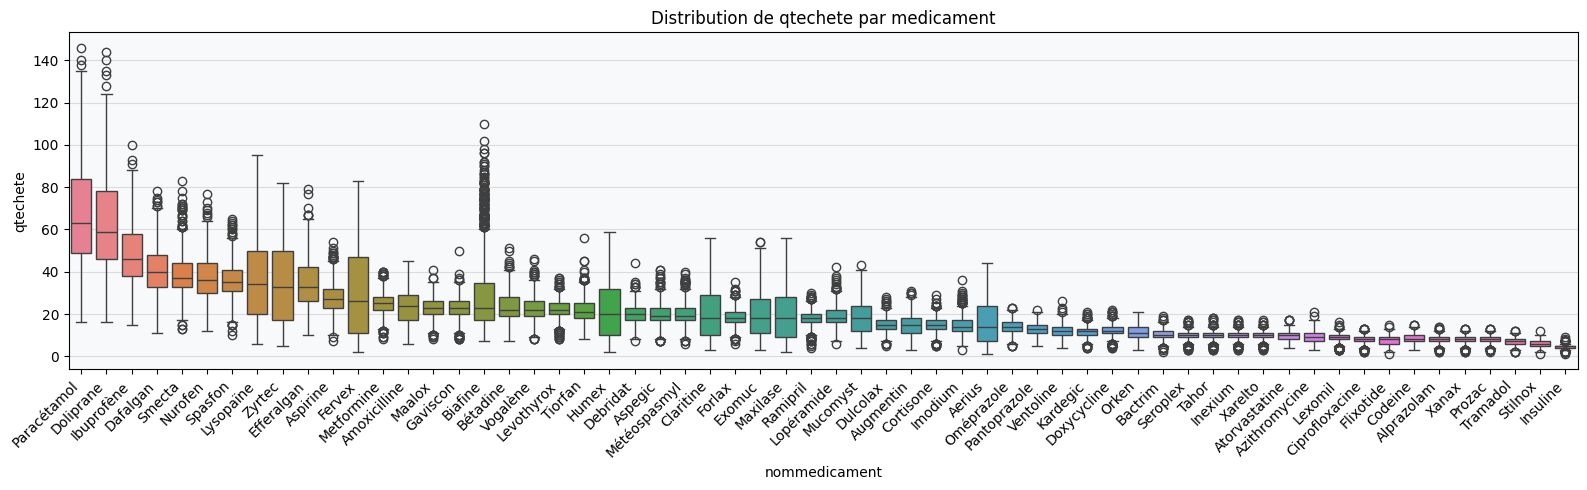

In [6]:
meds_order = df.groupby('nommedicament')['qtechete'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df, x='nommedicament', y='qtechete', order=meds_order, palette='husl', ax=ax)
ax.set_title('Distribution de qtechete par medicament')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Analyse temporelle

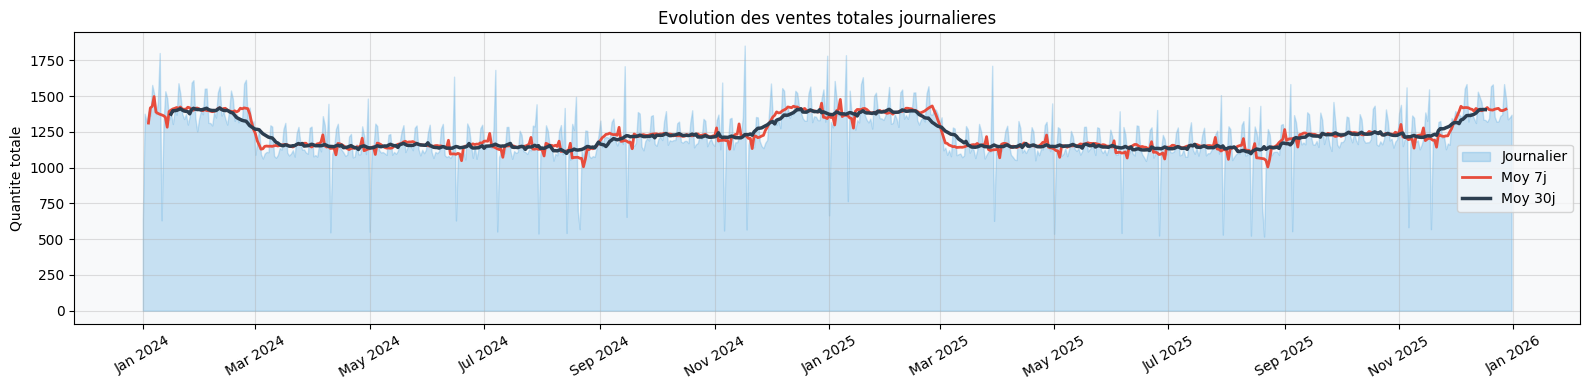

In [7]:
daily = df.groupby('date')['qtechete'].sum().reset_index()
daily['roll7'] = daily['qtechete'].rolling(7, center=True).mean()
daily['roll30'] = daily['qtechete'].rolling(30, center=True).mean()
fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily['date'], daily['qtechete'], alpha=0.25, color='#3498db', label='Journalier')
ax.plot(daily['date'], daily['roll7'], color='#e74c3c', lw=2, label='Moy 7j')
ax.plot(daily['date'], daily['roll30'], color='#2c3e50', lw=2.5, label='Moy 30j')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.set_title('Evolution des ventes totales journalieres')
ax.set_ylabel('Quantite totale')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Saisonnalite

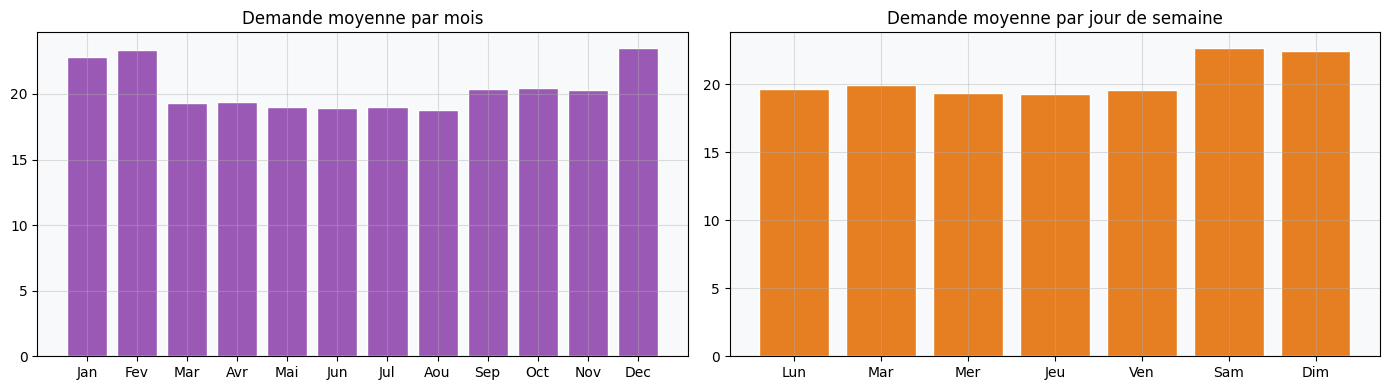

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
month_names = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
monthly = df.groupby('month')['qtechete'].mean()
axes[0].bar(monthly.index, monthly.values, color='#9b59b6', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Demande moyenne par mois')
day_names = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
dow = df.groupby('day_of_week')['qtechete'].mean()
axes[1].bar(dow.index, dow.values, color='#e67e22', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('Demande moyenne par jour de semaine')
plt.tight_layout()
plt.show()

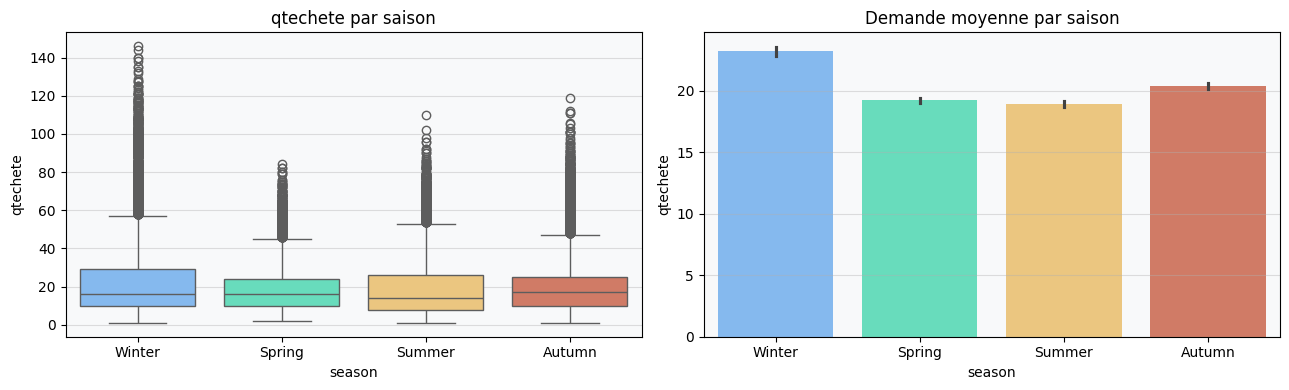

In [9]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['#74b9ff', '#55efc4', '#fdcb6e', '#e17055']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='season', y='qtechete', order=season_order, palette=season_colors, ax=axes[0])
axes[0].set_title('qtechete par saison')
sns.barplot(data=df, x='season', y='qtechete', order=season_order, palette=season_colors, estimator=np.mean, ax=axes[1])
axes[1].set_title('Demande moyenne par saison')
plt.tight_layout()
plt.show()

## 7. Jours feries et week-ends

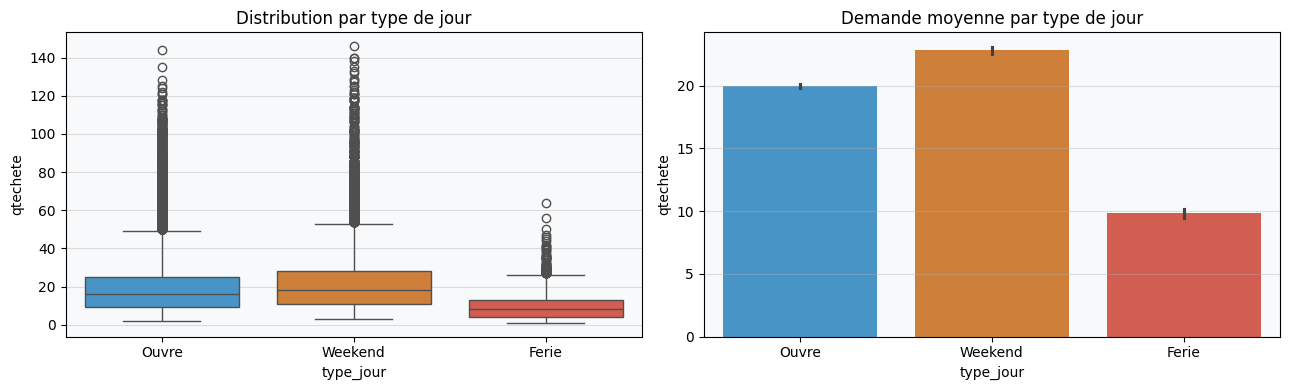

            mean  median  count
type_jour                      
Ferie       9.85     8.0   1560
Ouvre      20.00    16.0  30060
Weekend    22.82    18.0  12240


In [10]:
df['type_jour'] = 'Ouvre'
df.loc[df['is_weekend'] == 1, 'type_jour'] = 'Weekend'
df.loc[df['jourférié'] == 1, 'type_jour'] = 'Ferie'
colors = {'Ouvre': '#3498db', 'Weekend': '#e67e22', 'Ferie': '#e74c3c'}
ordre = ['Ouvre', 'Weekend', 'Ferie']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='type_jour', y='qtechete', order=ordre, palette=colors, ax=axes[0])
axes[0].set_title('Distribution par type de jour')
sns.barplot(data=df, x='type_jour', y='qtechete', order=ordre, palette=colors, estimator=np.mean, ax=axes[1])
axes[1].set_title('Demande moyenne par type de jour')
plt.tight_layout()
plt.show()
print(df.groupby('type_jour')['qtechete'].agg(['mean', 'median', 'count']).round(2))

## 8. Analyse du stock

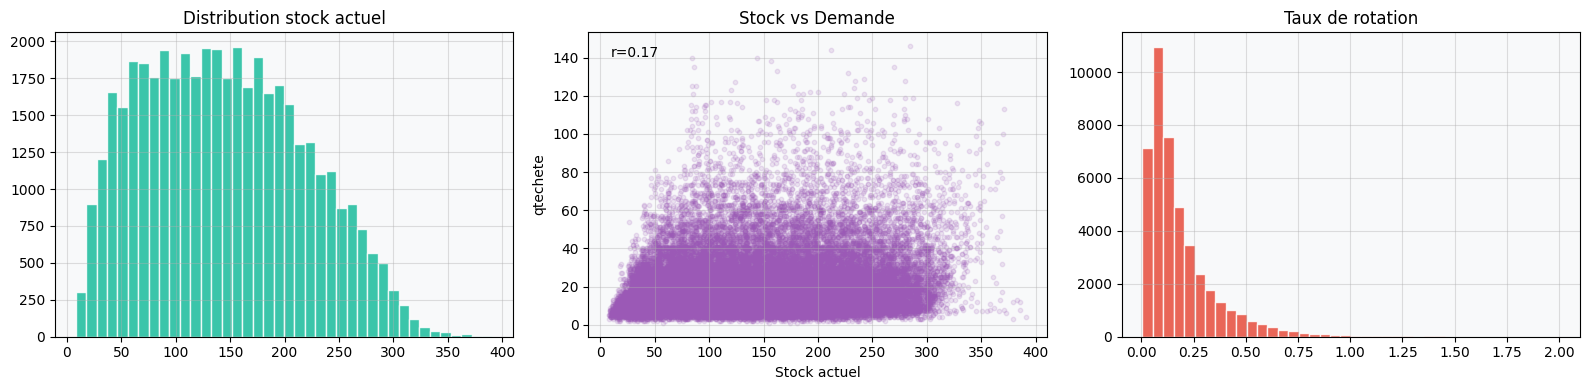

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['stock_actuel'], bins=40, color='#1abc9c', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution stock actuel')
axes[1].scatter(df['stock_actuel'], df['qtechete'], alpha=0.15, s=10, color='#9b59b6')
axes[1].set_xlabel('Stock actuel')
axes[1].set_ylabel('qtechete')
axes[1].set_title('Stock vs Demande')
corr = df[['stock_actuel', 'qtechete']].corr().iloc[0, 1]
axes[1].text(0.05, 0.92, 'r=' + str(round(corr, 3)), transform=axes[1].transAxes)
taux = df['qtechete'] / (df['stock_actuel'] + 1)
axes[2].hist(taux.clip(0, 2), bins=40, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[2].set_title('Taux de rotation')
plt.tight_layout()
plt.show()

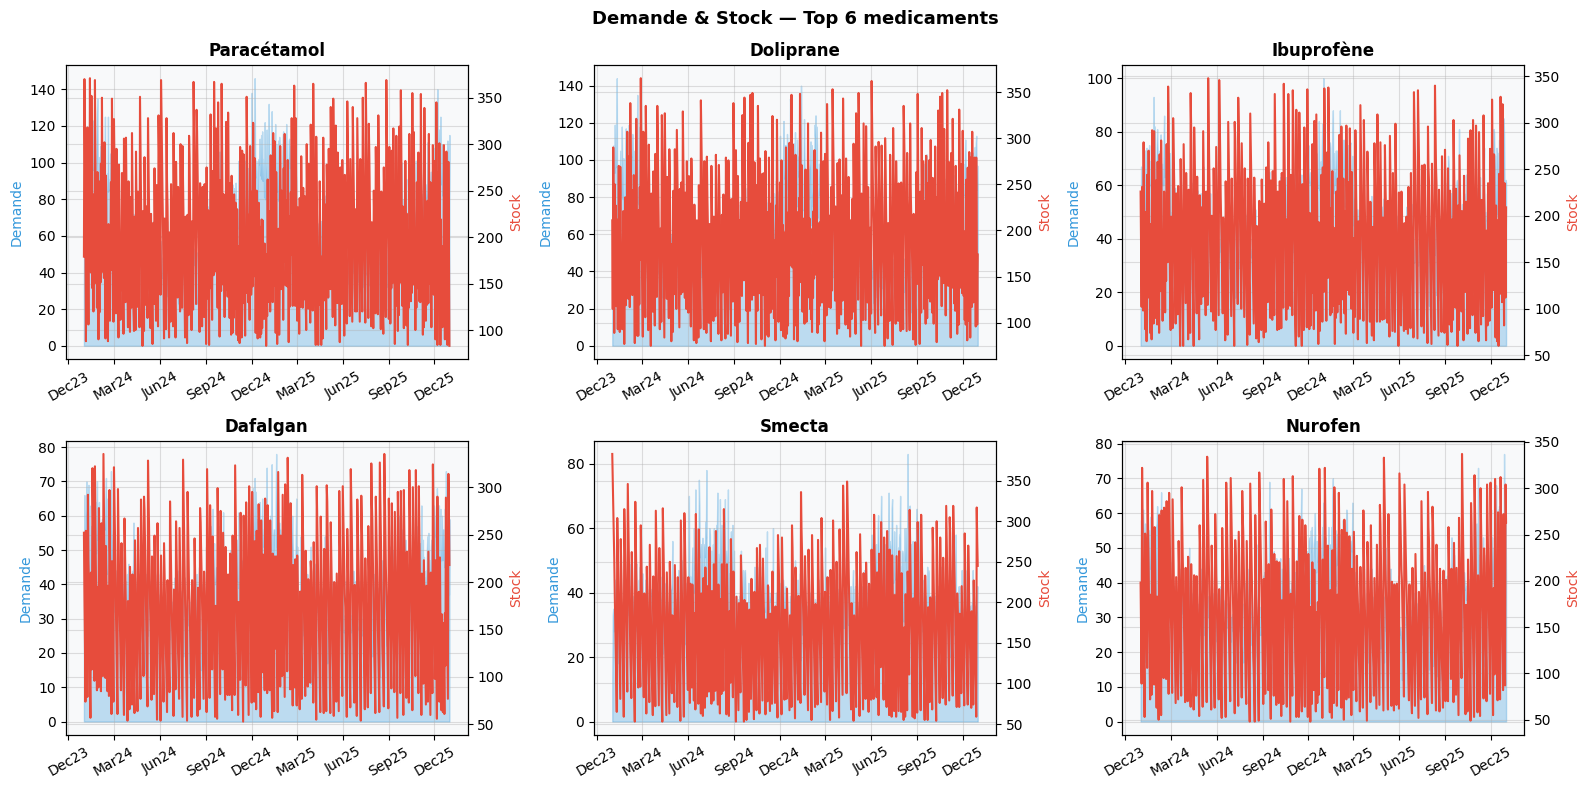

In [12]:
top6 = df.groupby('nommedicament')['qtechete'].sum().nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, med in zip(axes.flatten(), top6):
    sub = df[df['nommedicament'] == med].sort_values('date')
    ax2 = ax.twinx()
    ax.fill_between(sub['date'], sub['qtechete'], alpha=0.3, color='#3498db', label='Demande')
    ax2.plot(sub['date'], sub['stock_actuel'], color='#e74c3c', lw=1.5, label='Stock')
    ax.set_title(med, fontweight='bold')
    ax.set_ylabel('Demande', color='#3498db')
    ax2.set_ylabel('Stock', color='#e74c3c')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Demande & Stock — Top 6 medicaments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Analyse des prix

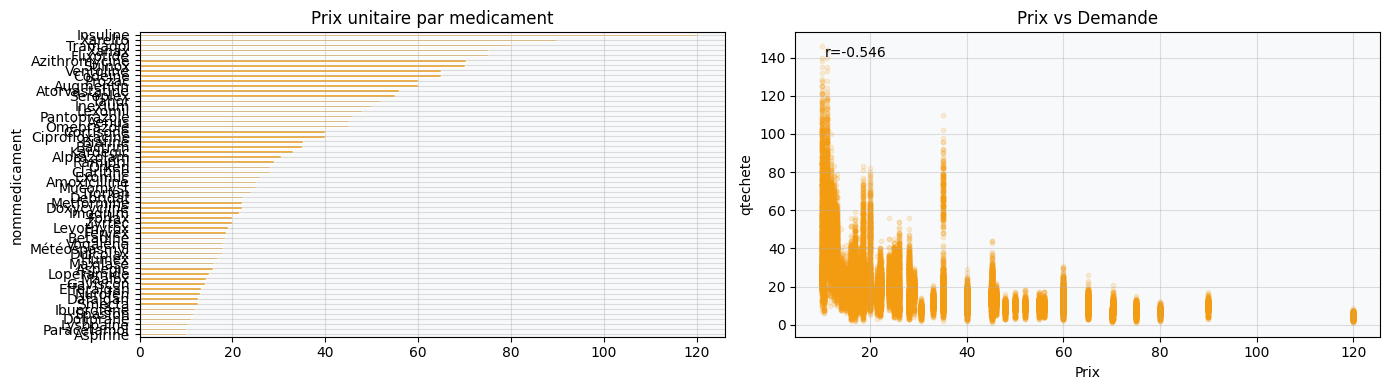

In [13]:
prix_med = df.groupby('nommedicament')['prix'].first().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
prix_med.plot(kind='barh', ax=axes[0], color='#f39c12', edgecolor='white')
axes[0].set_title('Prix unitaire par medicament')
axes[1].scatter(df['prix'], df['qtechete'], alpha=0.15, s=10, color='#f39c12')
axes[1].set_xlabel('Prix')
axes[1].set_ylabel('qtechete')
axes[1].set_title('Prix vs Demande')
corr_p = df[['prix', 'qtechete']].corr().iloc[0, 1]
axes[1].text(0.05, 0.92, 'r=' + str(round(corr_p, 3)), transform=axes[1].transAxes)
plt.tight_layout()
plt.show()

## 10. Matrice de correlation

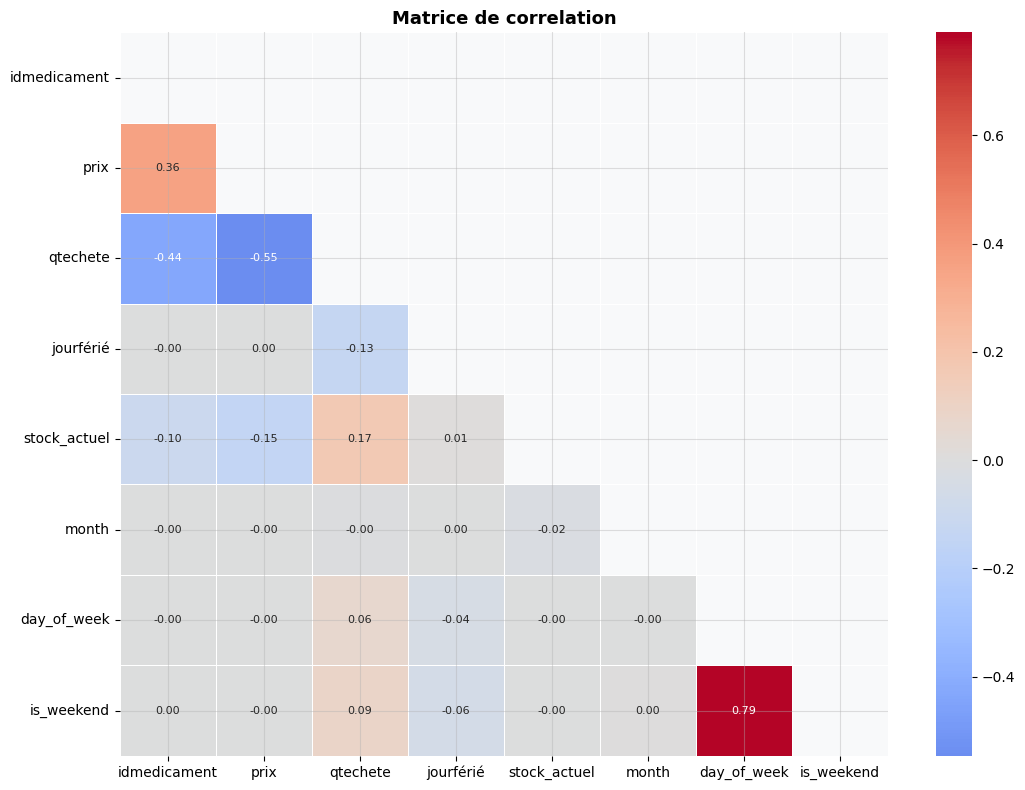

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Matrice de correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
target_corr = corr_matrix['qtechete'].drop('qtechete').sort_values(key=abs, ascending=False)
print('Top correlations avec qtechete:')
print(target_corr.head(10).to_string())

Top correlations avec qtechete:
prix           -0.546270
idmedicament   -0.436449
stock_actuel    0.169698
jourférié      -0.128871
is_weekend      0.086618
day_of_week     0.064127
month          -0.003830


## 11. Heatmap temporelle

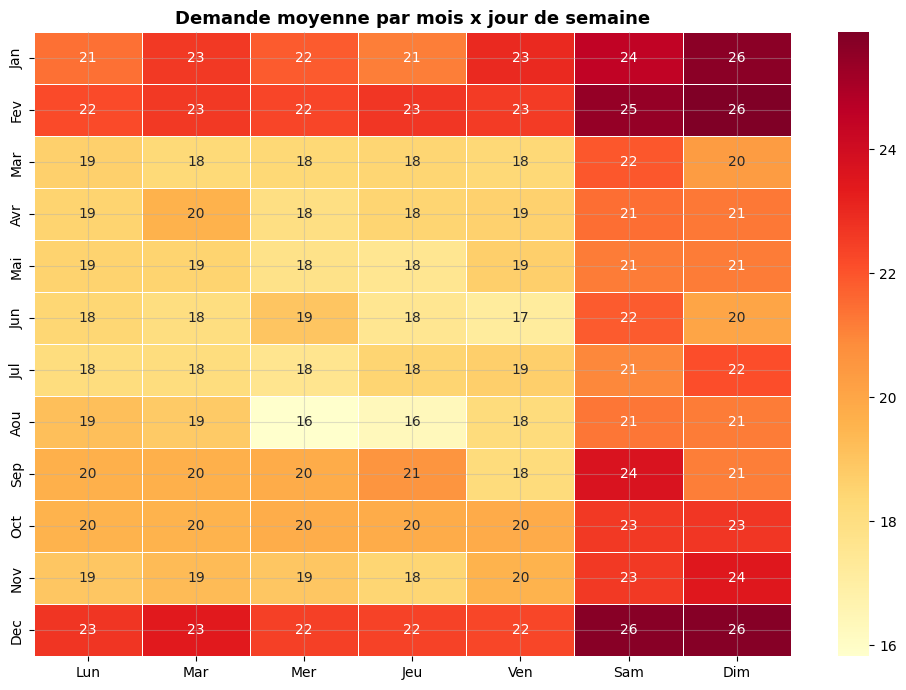

In [16]:
pivot = df.groupby(['month', 'day_of_week'])['qtechete'].mean().unstack()
pivot.columns = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
pivot.index = ['Jan', 'Fev', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aou', 'Sep', 'Oct', 'Nov', 'Dec']
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Demande moyenne par mois x jour de semaine', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Detection des outliers

Seuil bas : -14.0
Seuil haut: 50.0
Outliers  : 2446 (5.6%)


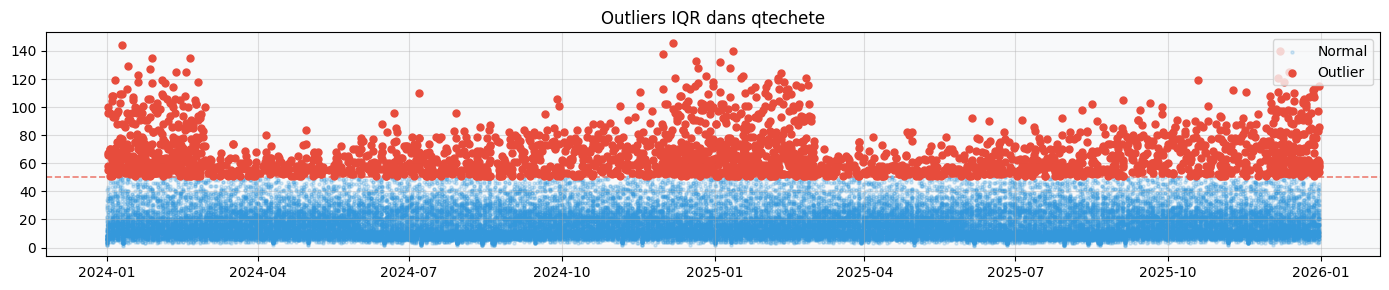

In [17]:
Q1 = df['qtechete'].quantile(0.25)
Q3 = df['qtechete'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['qtechete'] < lower) | (df['qtechete'] > upper)]
print('Seuil bas :', round(lower, 1))
print('Seuil haut:', round(upper, 1))
print('Outliers  :', len(outliers), '(' + str(round(len(outliers)/len(df)*100, 1)) + '%)')
fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(df['date'], df['qtechete'], alpha=0.2, s=5, color='#3498db', label='Normal')
ax.scatter(outliers['date'], outliers['qtechete'], color='#e74c3c', s=25, zorder=5, label='Outlier')
ax.axhline(upper, color='#e74c3c', linestyle='--', lw=1.2, alpha=0.7)
ax.set_title('Outliers IQR dans qtechete')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Resume final

In [18]:
print('=' * 55)
print('SYNTHESE EDA')
print('=' * 55)
print('Observations  :', len(df))
print('Medicaments   :', df['idmedicament'].nunique())
print('Periode       :', str(df['date'].min().date()), '->', str(df['date'].max().date()))
print('Target mean   :', round(df['qtechete'].mean(), 1))
print('Target std    :', round(df['qtechete'].std(), 1))
print('Target min/max:', df['qtechete'].min(), '/', df['qtechete'].max())
print('Skewness      :', round(df['qtechete'].skew(), 3))
print('Outliers IQR  :', len(outliers))
print()
print('Top correlations absolues avec qtechete:')
for feat, val in target_corr.head(8).items():
    bar = chr(9608) * int(abs(val) * 20)
    print('  ' + feat.ljust(28) + str(round(val, 3)).rjust(7) + '  ' + bar)
print()
print('EDA terminee — dataset pret pour la modelisation.')

SYNTHESE EDA
Observations  : 43860
Medicaments   : 60
Periode       : 2024-01-01 -> 2025-12-31
Target mean   : 20.4
Target std    : 15.8
Target min/max: 1 / 146
Skewness      : 2.138
Outliers IQR  : 2446

Top correlations absolues avec qtechete:
  prix                         -0.546  ██████████
  idmedicament                 -0.436  ████████
  stock_actuel                   0.17  ███
  jourférié                    -0.129  ██
  is_weekend                    0.087  █
  day_of_week                   0.064  █
  month                        -0.004  

EDA terminee — dataset pret pour la modelisation.
